# 03. Cross-Section CAT Comparison

This notebook culminates in the computational-accuracy-vs-time (CAT)
comparison between ROSE ROM configurations and the optimized
potential-predictor LROM.

The full CAT calculation is the most expensive part of the demo because
it trains many partial-wave channels and times online cross-section
evaluations.  For portability, this notebook first renders the saved
point clouds from the clean run.  The bottom section documents the
recomputation path and the exact quantities that are timed.

In [1]:
from pathlib import Path
import importlib
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "lrom_demo").exists() and (ROOT.parent / "lrom_demo").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUT = ROOT / "outputs" / Path(__file__).stem if "__file__" in globals() else ROOT / "outputs" / "notebook_outputs"
OUT.mkdir(parents=True, exist_ok=True)

import rose
from lrom_demo import rose_rom
rose_rom = importlib.reload(rose_rom)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

print("ROSE imported from:", rose.__file__)
print("output folder:", OUT)

ROSE imported from: /home/pablo/.local/lib/python3.10/site-packages/rose/__init__.py
output folder: /home/pablo/research-projects/new-project-3/clean_lrom_demo/outputs/notebook_outputs


## Load Saved CAT Point Clouds

In [2]:
cache = ROOT / "outputs" / "cached_cat"
rose_cat = np.load(cache / "rose_cat_point_clouds.npz", allow_pickle=True)
lrom_cat = np.load(cache / "lrom_cat_point_clouds_fast_packed.npz", allow_pickle=True)
full_lrom_cat_path = cache / "lrom_cat_point_clouds.npz"
fallback_full_lrom_cat_path = ROOT.parent / "outputs" / "phase3l_lrom_online_optimization" / "lrom_cat_point_clouds.npz"
full_lrom_cat = None
if full_lrom_cat_path.exists():
    full_lrom_cat = np.load(full_lrom_cat_path, allow_pickle=True)
elif fallback_full_lrom_cat_path.exists():
    full_lrom_cat = np.load(fallback_full_lrom_cat_path, allow_pickle=True)

print("ROSE labels:", rose_cat["labels"])
print("LROM labels:", lrom_cat["labels"])
if full_lrom_cat is not None:
    print("full LROM/error labels:", full_lrom_cat["labels"])

ROSE labels: ['ROSE (4, 4)' 'ROSE (4, 8)' 'ROSE (7, 7)' 'ROSE (10, 10)' 'ROSE (15, 15)']
LROM labels: ['linear LROM packed' 'K=3 packed' 'K=3 fast-packed' 'K=6 packed'
 'K=6 fast-packed' 'K=9 packed' 'K=9 fast-packed' 'K=12 packed'
 'K=12 fast-packed']
full LROM/error labels: ['LS floor' 'ROSE ROM' 'linear LROM' 'K=3' 'K=6' 'K=9' 'K=12']


The plotted metric is the **median pointwise relative cross-section
error** over angle for each held-out parameter sample.  The x-axis is
the online evaluation time per sample: from receiving new parameter
values to returning the cross section.  Predictor evaluation is included
in the LROM timing; precomputable quantities are not.

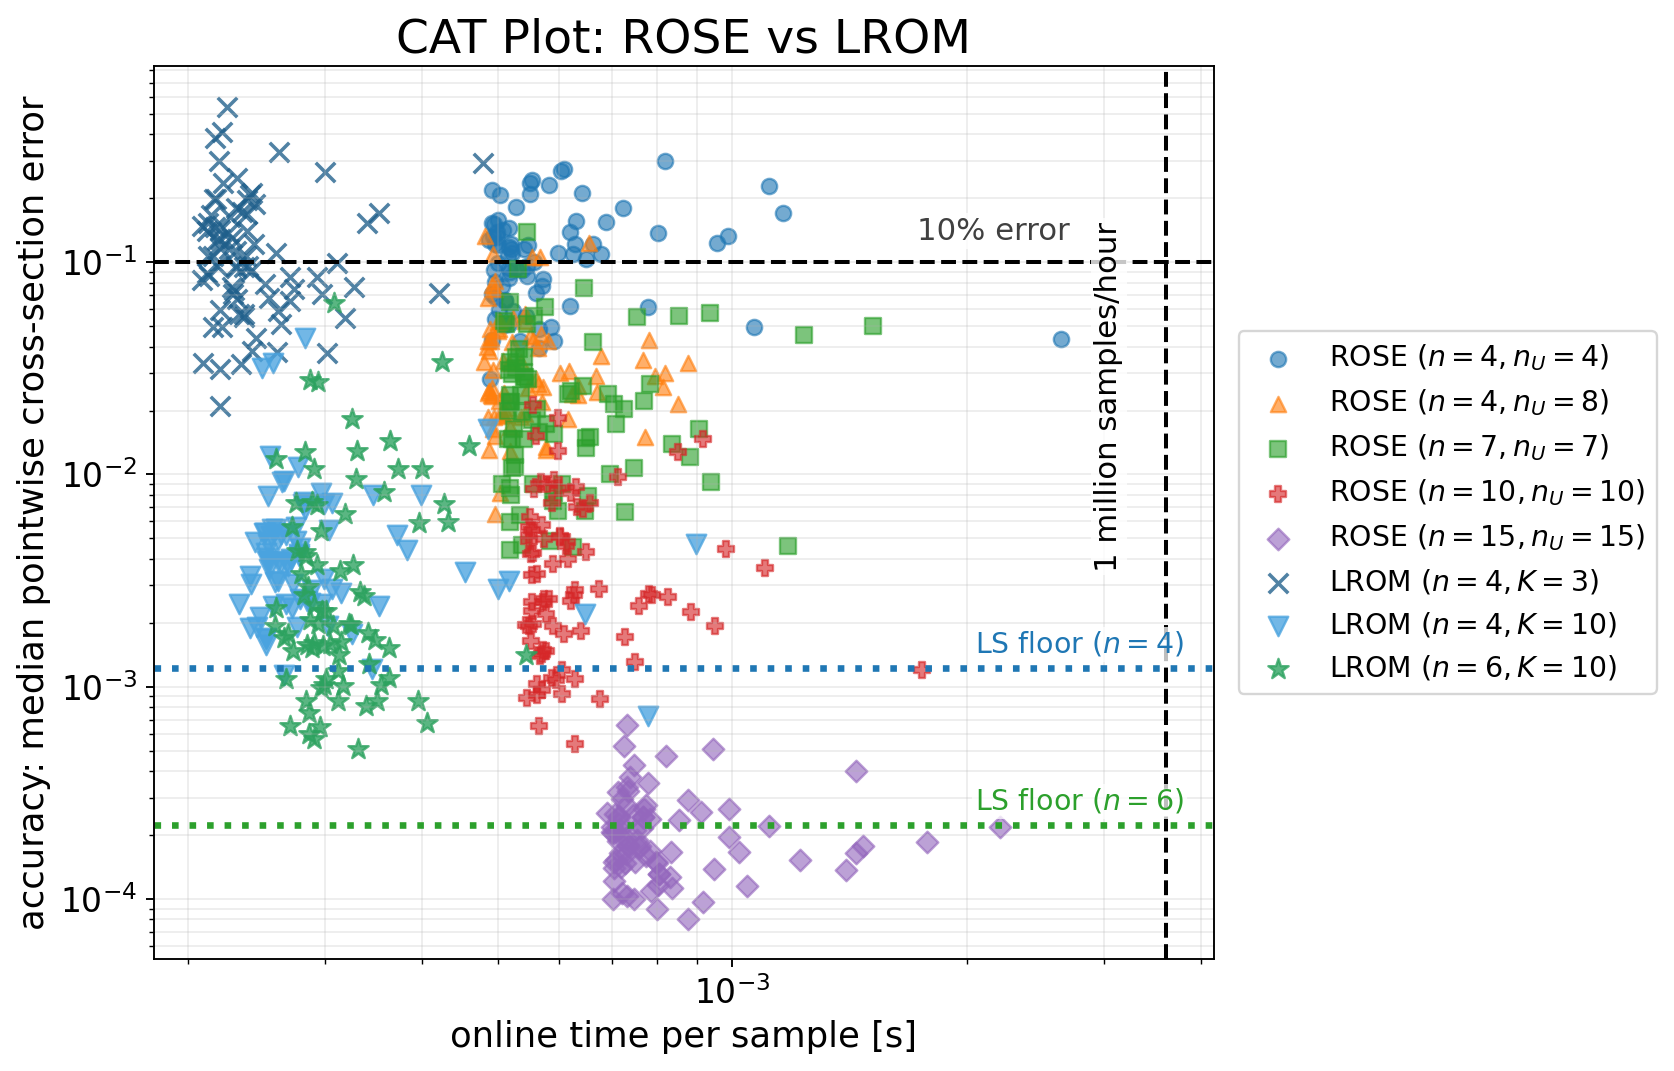

In [3]:
from lrom_demo import cross_section_recompute as xs_recompute
xs_recompute = importlib.reload(xs_recompute)

def compact_label(label):
    return str(label).replace(", ", ",")

def rose_config_label(label):
    raw = compact_label(label)
    nums = raw.removeprefix("ROSE (").removesuffix(")").split(",")
    if len(nums) == 2:
        return rf"ROSE ($n={nums[0]}, n_U={nums[1]}$)"
    return raw

def lrom_cache_path(n_phi, k):
    return cache / f"compact_lrom_cat_n{n_phi}_u10_k{k}.npz"

# These caches take several minutes each to generate, so the notebook
# loads them by default.  Set this flag to True when intentionally
# refreshing the compact LROM CAT data.
RECOMPUTE_COMPACT_LROM_CAT = False

compact_specs = [(4, 3), (4, 10), (6, 10)]
compact_data = {}
missing = []
old_constants = (xs_recompute.N_PHI, xs_recompute.N_U, xs_recompute.K_PREDICTOR)
try:
    for n_phi, k in compact_specs:
        path = lrom_cache_path(n_phi, k)
        if RECOMPUTE_COMPACT_LROM_CAT or not path.exists():
            if not RECOMPUTE_COMPACT_LROM_CAT:
                missing.append(path.name)
                continue
            xs_recompute.N_PHI = n_phi
            xs_recompute.N_U = 10
            xs_recompute.K_PREDICTOR = k
            xs_recompute.recompute(path, force=True)
        if path.exists():
            compact_data[(n_phi, k)] = np.load(path, allow_pickle=True)
finally:
    xs_recompute.N_PHI, xs_recompute.N_U, xs_recompute.K_PREDICTOR = old_constants

if missing:
    print("Missing compact CAT caches:", missing)
    print("Set RECOMPUTE_COMPACT_LROM_CAT = True in this cell to generate them.")

fig, ax = plt.subplots(figsize=(12.8, 6.4), dpi=170)

rose_colors = {
    "ROSE (4,4)": "#1f77b4",
    "ROSE (4,8)": "#ff7f0e",
    "ROSE (7,7)": "#2ca02c",
    "ROSE (10,10)": "#d62728",
    "ROSE (15,15)": "#9467bd",
}
rose_markers = {
    "ROSE (4,4)": "o",
    "ROSE (4,8)": "^",
    "ROSE (7,7)": "s",
    "ROSE (10,10)": "P",
    "ROSE (15,15)": "D",
}
for i, label in enumerate(rose_cat["labels"]):
    key = compact_label(label)
    ax.scatter(
        rose_cat["times"][i],
        rose_cat["median_pointwise"][i],
        s=42,
        alpha=0.62,
        color=rose_colors.get(key, "0.4"),
        marker=rose_markers.get(key, "o"),
        label=rose_config_label(key),
    )

lrom_styles = {
    (4, 3): ("#1f5f8b", "x"),
    (4, 10): ("#4aa3df", "v"),
    (6, 3): ("#7b3294", "+"),
    (6, 10): ("#2ca25f", "*"),
}
for (n_phi, k), data in compact_data.items():
    methods = [str(m) for m in data["methods"]]
    predictor_row = methods.index("predictor LROM")
    color, marker = lrom_styles[(n_phi, k)]
    ax.scatter(
        data["test_times"][predictor_row],
        data["test_median_pointwise"][predictor_row],
        s=68 if marker != "*" else 82,
        alpha=0.78,
        color=color,
        marker=marker,
        label=rf"LROM ($n={n_phi}, K={k}$)",
    )

# Noise floors are accuracy limits, not online emulators, so represent
# them as horizontal lines.
floor_styles = {4: ("#1f77b4", ":"), 6: ("#2ca02c", ":")}
floor_values = {}
for n_phi in [4, 6]:
    floors = [d for (n, _k), d in compact_data.items() if n == n_phi]
    if not floors:
        continue
    methods = [str(m) for m in floors[0]["methods"]]
    floor_row = methods.index("LS floor")
    floor = float(np.median(floors[0]["test_median_pointwise"][floor_row]))
    color, style = floor_styles[n_phi]
    floor_values[n_phi] = floor
    ax.axhline(floor, color=color, ls=style, lw=2.8)
    ax.annotate(
        rf"LS floor ($n={n_phi}$)",
        xy=(0.985, floor),
        xycoords=("axes fraction", "data"),
        xytext=(-6, 4),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=12,
        color=color,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5),
    )

ax.axhline(0.10, color="k", ls="--", lw=1.7)
ax.annotate(
    "10% error",
    xy=(0.72, 0.10),
    xycoords=("axes fraction", "data"),
    xytext=(0, 7),
    textcoords="offset points",
    ha="left",
    va="bottom",
    fontsize=13,
    color="0.25",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.78, pad=1.5),
)
million_per_hour = 3600 / 1e6
ax.axvline(million_per_hour, color="k", ls="--", lw=1.7)
ax.annotate(
    "1 million samples/hour",
    xy=(million_per_hour, 0.63),
    xycoords=("data", "axes fraction"),
    xytext=(-18, 0),
    textcoords="offset points",
    rotation=90,
    va="center",
    ha="right",
    fontsize=13,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.78, pad=1.5),
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("online time per sample [s]", fontsize=15)
ax.set_ylabel("accuracy: median pointwise cross-section error", fontsize=15)
ax.set_title("CAT Plot: ROSE vs LROM", fontsize=20)
ax.tick_params(axis="both", which="major", labelsize=14)
ax.tick_params(axis="both", which="minor", labelsize=12)
ax.grid(True, which="both", alpha=0.22)
ax.legend(
    ncol=1,
    fontsize=12.0,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=True,
)
fig.tight_layout(rect=[0, 0, 0.78, 1])
fig.savefig(OUT / "clean_rose_vs_fast_lrom_cat.png", dpi=240, bbox_inches="tight")
display(fig)
plt.close(fig)

## Representative Cross Sections

The CAT plot compresses each test parameter point into one error and
one timing number.  Here we recompute and cache the raw cross-section
curves so the representative observable-space plots are generated from
arrays, not from a pre-rendered image.

In [4]:
from lrom_demo import cross_section_recompute as xs_recompute
xs_recompute = importlib.reload(xs_recompute)

raw_xs_cache = cache / "recomputed_cross_section_data_u10_k10.npz"
xsd = xs_recompute.recompute(raw_xs_cache, force=False)
print("raw cross-section cache:", raw_xs_cache)
print("recompute seconds stored in cache:", float(xsd["recompute_seconds"]))

method_legend = pd.DataFrame(
    [
        ("FOM", "full ROSE solve"),
        ("LS floor", "best central-basis cross-section reconstruction (n=4)"),
        ("ROSE ROM", "standard ROSE ROM (n=4, n_U=10)"),
        ("linear LROM", "central RF-LROM (n=4, K=10 raw optical-parameter predictors)"),
        ("predictor LROM", "central RF-LROM (n=4, K=10 potential predictors)"),
    ],
    columns=["curve", "configuration"],
)
display(method_legend)

raw cross-section cache: /home/pablo/research-projects/new-project-3/clean_lrom_demo/outputs/cached_cat/recomputed_cross_section_data_u10_k10.npz
recompute seconds stored in cache: 365.7082911780017


,curve,configuration
0,FOM,full ROSE solve
1,LS floor,best central-basis cross-section reconstructio...
2,ROSE ROM,"standard ROSE ROM (n=4, n_U=10)"
3,linear LROM,"central RF-LROM (n=4, K=10 raw optical-paramet..."
4,predictor LROM,"central RF-LROM (n=4, K=10 potential predictors)"


Choose which held-out test samples to show in the representative
cross-section panels.  The default values below were selected because
the linear LROM visibly fails while the predictor LROM remains close to
the FOM curve.

In [5]:
REPRESENTATIVE_TEST_INDICES = [51, 63, 79]

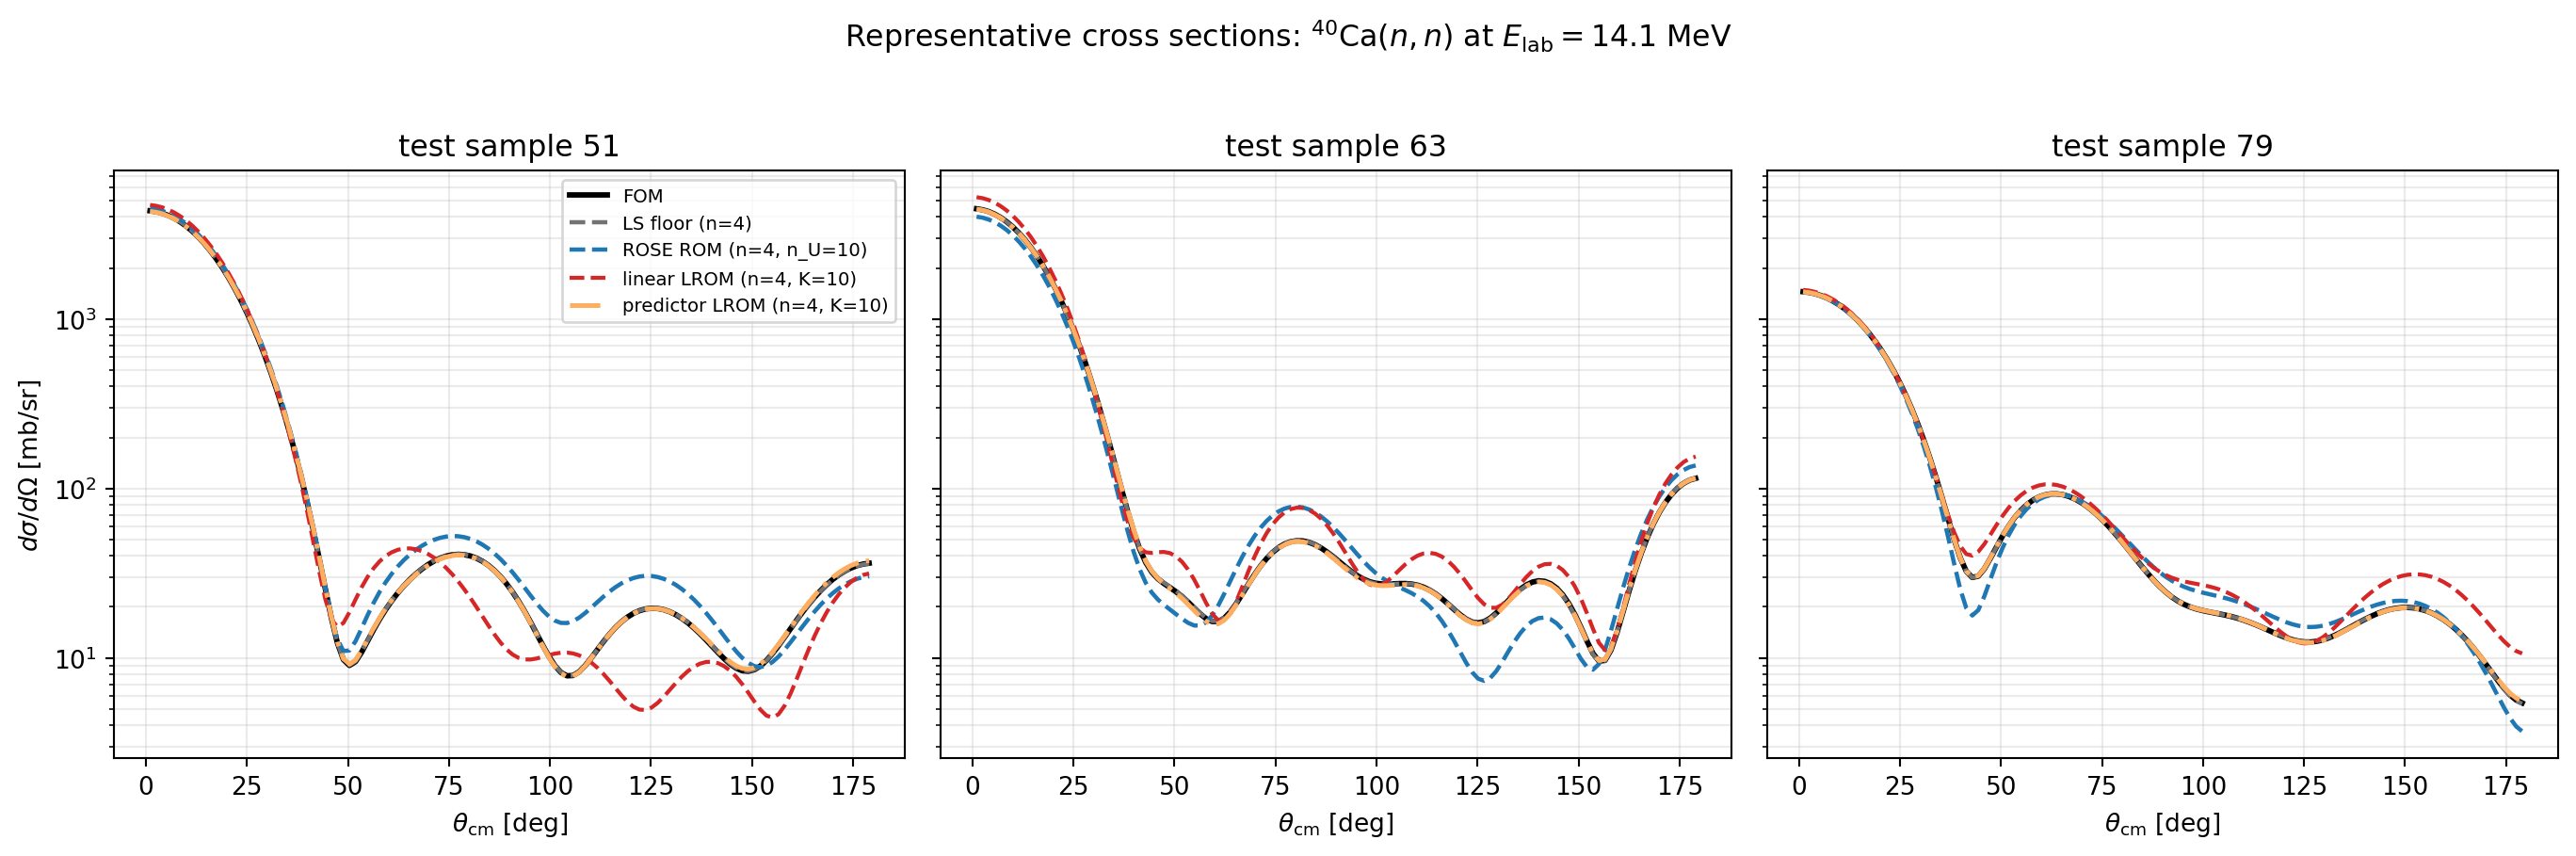

,Vv,Wv,Wd,Vso,Rv,Rd,Rso,av,ad,aso
test sample 51,54.101400,1.848800,-8.201700,5.649400,4.792900,5.017700,3.880800,0.580600,0.530900,0.704700
test sample 63,49.941700,1.886400,-6.617200,5.723000,4.677200,4.566400,2.830600,0.770800,0.624700,0.529700
test sample 79,38.856200,1.775800,-5.818400,6.959900,3.761400,3.987300,3.542000,0.543900,0.492400,0.685100


,Vv,Wv,Wd,Vso,Rv,Rd,Rso,av,ad,aso
test sample 51,15.800000,7.300000,-13.300000,-7.400000,18.200000,13.900000,12.400000,-13.600000,-1.300000,17.500000
test sample 63,6.900000,9.500000,8.500000,-6.200000,15.400000,3.700000,-18.100000,14.700000,16.100000,-11.700000
test sample 79,-16.800000,3.000000,19.600000,14.100000,-7.200000,-9.500000,2.500000,-19.000000,-8.500000,14.200000


In [6]:
chosen = np.asarray(REPRESENTATIVE_TEST_INDICES, dtype=int)
if chosen.ndim != 1 or len(chosen) != 3:
    raise ValueError("REPRESENTATIVE_TEST_INDICES must contain exactly three test-sample indices.")
if np.any(chosen < 0) or np.any(chosen >= len(xsd["test_samples"])):
    raise ValueError(f"Representative indices must be between 0 and {len(xsd['test_samples']) - 1}.")

angles_deg = xsd["angles_deg"]
curves = [
    ("FOM", "xs_test_fom", "black", "-", 2.2),
    ("LS floor (n=4)", "xs_test_ls", "0.45", "--", 1.7),
    ("ROSE ROM (n=4, n_U=10)", "xs_test_rose", "tab:blue", "--", 1.7),
    ("linear LROM (n=4, K=10)", "xs_test_linear", "tab:red", "--", 1.6),
    ("predictor LROM (n=4, K=10)", "xs_test_predictor", "#fdae61", "-.", 1.9),
]

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.6), dpi=190, sharey=True)
for ax, idx in zip(axes, chosen):
    for label, key, color, style, lw in curves:
        ax.plot(angles_deg, xsd[key][idx], style, color=color, lw=lw, label=label)
    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.25)
    ax.set_xlabel(r"$\theta_{\rm cm}$ [deg]")
    ax.set_title(f"test sample {idx}")
axes[0].set_ylabel(r"$d\sigma/d\Omega$ [mb/sr]")
axes[0].legend(fontsize=7.5)
fig.suptitle(r"Representative cross sections: $^{40}$Ca$(n,n)$ at $E_{\rm lab}=14.1$ MeV", y=1.03)
fig.tight_layout()
fig.savefig(OUT / "representative_cross_sections_high_res.png", dpi=320, bbox_inches="tight")
display(fig)
plt.close(fig)

chosen_samples = pd.DataFrame(
    xsd["test_samples"][chosen],
    index=[f"test sample {idx}" for idx in chosen],
    columns=xsd["feature_names"],
)
chosen_percent = 100 * (chosen_samples - xsd["central_sample"]) / np.maximum(np.abs(xsd["central_sample"]), 1e-30)
display(chosen_samples.round(4).style.set_caption("Parameter values for representative cross-section test samples"))
display(chosen_percent.round(1).style.set_caption("Percent change from central optical parameters"))

## Cross-Section Error Distributions

The violins below show train and test cross-section error
distributions over the same all-parameter box used for the
representative cross sections.

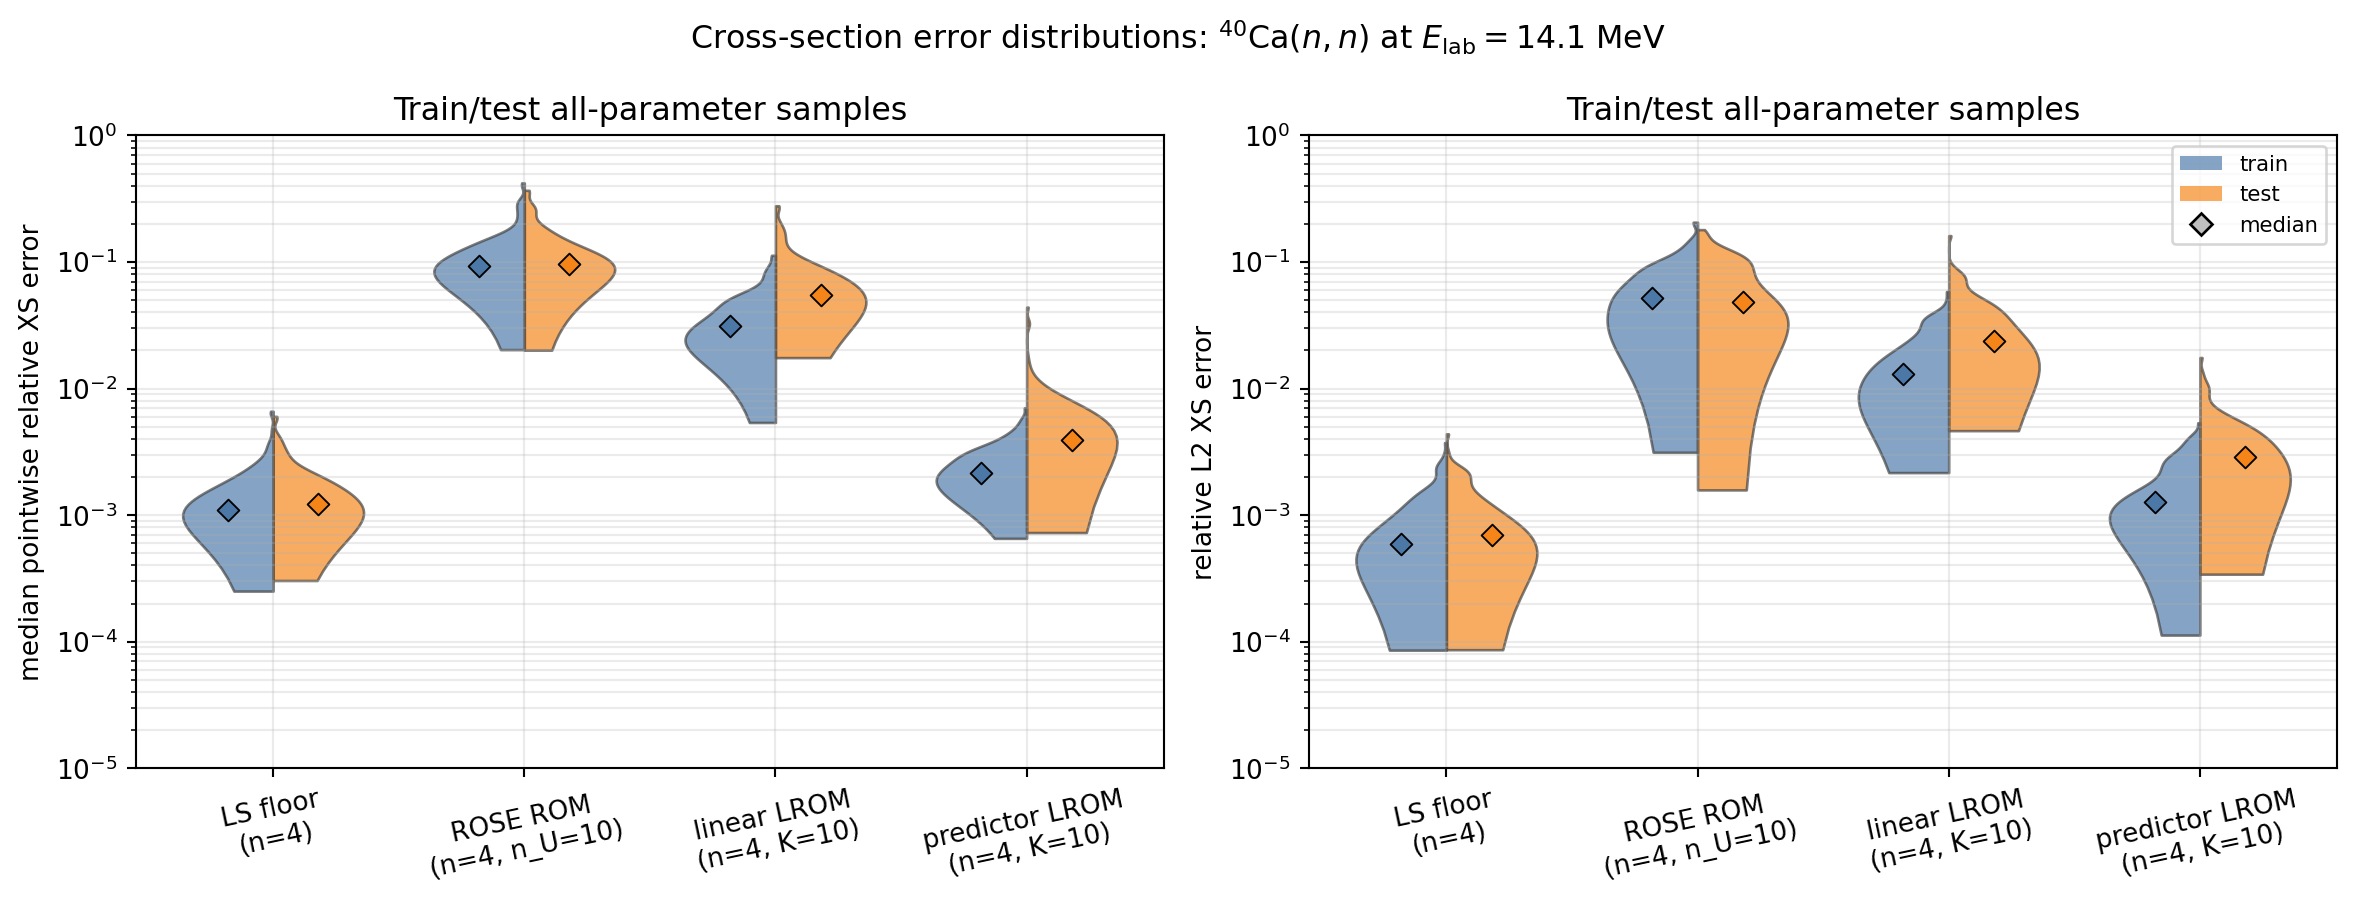

In [7]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def split_violin(ax, values, x0, side, color, width=0.72):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values) & (values > 0)]
    if values.size == 0:
        return
    parts = ax.violinplot(
        [values],
        positions=[x0],
        widths=width,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    for body in parts["bodies"]:
        verts = body.get_paths()[0].vertices
        if side == "left":
            verts[:, 0] = np.minimum(verts[:, 0], x0)
        else:
            verts[:, 0] = np.maximum(verts[:, 0], x0)
        body.set_facecolor(color)
        body.set_edgecolor("0.25")
        body.set_alpha(0.68)
    return parts

method_labels = [
    "LS floor\n(n=4)",
    "ROSE ROM\n(n=4, n_U=10)",
    "linear LROM\n(n=4, K=10)",
    "predictor LROM\n(n=4, K=10)",
]
metric_names = [
    ("median_pointwise", "median pointwise relative XS error"),
    ("l2", "relative L2 XS error"),
]
metric_arrays = {
    "median_pointwise": ("train_median_pointwise", "test_median_pointwise"),
    "l2": ("train_l2", "test_l2"),
}
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), dpi=190)
train_color = "#4C78A8"
test_color = "#F58518"
display_floor = 1e-5
for ax, (metric, ylabel) in zip(axes, metric_names):
    train_key, test_key = metric_arrays[metric]
    all_values = []
    for xpos, label in enumerate(method_labels, start=1):
        train_vals = np.clip(xsd[train_key][xpos - 1], display_floor, None)
        test_vals = np.clip(xsd[test_key][xpos - 1], display_floor, None)
        all_values.extend([train_vals, test_vals])
        split_violin(ax, train_vals, xpos, "left", train_color)
        split_violin(ax, test_vals, xpos, "right", test_color)
        ax.scatter(xpos - 0.18, np.median(train_vals), marker="D", s=34, color=train_color, edgecolor="black", linewidth=0.7, zorder=6)
        ax.scatter(xpos + 0.18, np.median(test_vals), marker="D", s=34, color=test_color, edgecolor="black", linewidth=0.7, zorder=6)
    ax.set_yscale("log")
    ax.set_xticks(range(1, len(method_labels) + 1), method_labels, rotation=12)
    ax.set_ylabel(ylabel)
    ax.grid(True, which="both", alpha=0.25)
    top = max(float(np.quantile(v, 0.98)) for v in all_values)
    ax.set_ylim(display_floor, max(1.0, 1.5 * top))
axes[0].set_title("Train/test all-parameter samples")
axes[1].set_title("Train/test all-parameter samples")
axes[1].legend(
    handles=[
        Patch(facecolor=train_color, alpha=0.68, label="train"),
        Patch(facecolor=test_color, alpha=0.68, label="test"),
        Line2D([], [], marker="D", linestyle="None", color="white", markerfacecolor="0.75", markeredgecolor="black", label="median"),
    ],
    loc="upper right",
    fontsize=8,
)
fig.suptitle(r"Cross-section error distributions: $^{40}$Ca$(n,n)$ at $E_{\rm lab}=14.1$ MeV")
fig.tight_layout()
fig.savefig(OUT / "cross_section_error_violins.png", dpi=320, bbox_inches="tight")
display(fig)
plt.close(fig)

## Summary Table

In [8]:
def summarize_clouds(data):
    rows = []
    for i, label in enumerate(data["labels"]):
        rows.append((str(label), np.median(data["times"][i]), np.median(data["median_pointwise"][i])))
    return rows

rows = summarize_clouds(rose_cat) + summarize_clouds(lrom_cat)
print(f"{'method':<22} {'median time [s]':>16} {'median error':>16}")
print("-" * 58)
for label, t, e in rows:
    print(f"{label:<22} {t:16.3e} {e:16.3e}")

method                  median time [s]     median error
----------------------------------------------------------
ROSE (4, 4)                   5.389e-04        1.101e-01
ROSE (4, 8)                   5.182e-04        2.948e-02
ROSE (7, 7)                   5.590e-04        1.978e-02
ROSE (10, 10)                 5.925e-04        2.800e-03
ROSE (15, 15)                 7.608e-04        1.878e-04
linear LROM packed            1.245e-04        5.534e-02
K=3 packed                    1.002e-03        1.026e-01
K=3 fast-packed               1.571e-04        1.026e-01
K=6 packed                    1.002e-03        1.727e-02
K=6 fast-packed               1.601e-04        1.727e-02
K=9 packed                    1.008e-03        4.274e-03
K=9 fast-packed               1.703e-04        4.274e-03
K=12 packed                   1.015e-03        2.939e-03
K=12 fast-packed              1.739e-04        2.939e-03


## Recomputing The CAT Plot

The saved cache is useful for presentations and quick reruns.  To
regenerate the point clouds from scratch:

1. train ROSE scattering-amplitude emulators for the desired
   `(n_phi, n_U)` configurations;
2. train one central predictor LROM per partial-wave channel;
3. time only the online stage: parameter values in, cross section out;
4. compute relative cross-section errors against FOM cross sections.

In the optimized LROM path, all channel-independent predictor work is
batched, Hankel/asymptotic quantities are precomputed through ROSE basis
objects, and each online sample only evaluates predictors, solves small
reduced systems, converts coefficients to S-matrix elements, and calls
ROSE's cross-section assembly.